In [410]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import numpy as np
warnings.filterwarnings('ignore')
%matplotlib inline

In [429]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

In [430]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [ ]:
train_df, val_df = train_test_split(train_df, test_size=0.01, random_state=42)

In [432]:
input_chars = set(''.join(train_df['data']))
input_vocab = ['<PAD>', '<UNK>', '<SOS>', '<EOS>'] + sorted(list(input_chars))
input_char_to_idx = {c: i for i, c in enumerate(input_vocab)}

In [433]:
output_vocab = ['<PAD>', '<SOS>', '<EOS>', '<UNK>'] + [str(i) for i in range(10)] + ['-']
output_char_to_idx = {c: i for i, c in enumerate(output_vocab)}
output_idx_to_char = {i: c for c, i in output_char_to_idx.items()}

In [434]:
max_input_length = max(len(data) for data in train_df['data']) + 1
max_output_length = 11  # 'dd-mm-yyyy' + <EOS>

In [435]:
def string_to_seq(s, char_to_idx, max_len, eos_token='<EOS>', pad_token='<PAD>', unk_token='<UNK>'):
    seq = [char_to_idx.get(c, char_to_idx[unk_token]) for c in s]
    seq.append(char_to_idx[eos_token])
    seq += [char_to_idx[pad_token]] * (max_len - len(seq))
    return seq

In [436]:
train_input_seqs = [string_to_seq(data, input_char_to_idx, max_input_length) for data in train_df['data']]
train_output_seqs = [string_to_seq(label, output_char_to_idx, max_output_length) for label in train_df['label']]
val_input_seqs = [string_to_seq(data, input_char_to_idx, max_input_length) for data in val_df['data']]
val_output_seqs = [string_to_seq(label, output_char_to_idx, max_output_length) for label in val_df['label']]

In [437]:
class DateDataset(Dataset):
    def __init__(self, input_seqs, output_seqs):
        self.input_seqs = input_seqs
        self.output_seqs = output_seqs
    
    def __len__(self):
        return len(self.input_seqs)
    
    def __getitem__(self, idx):
        return torch.tensor(self.input_seqs[idx], dtype=torch.long), torch.tensor(self.output_seqs[idx], dtype=torch.long)

In [438]:
train_dataset = DateDataset(train_input_seqs, train_output_seqs)
val_dataset = DateDataset(val_input_seqs, val_output_seqs)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [439]:
class Encoder(nn.Module):
    def __init__(self, input_vocab_size, embedding_dim, hidden_size):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(input_vocab_size, embedding_dim)
        self.dropout = nn.Dropout(0.2)
        self.gru = nn.GRU(embedding_dim, hidden_size, num_layers=3, bidirectional=True, batch_first=True, dropout=0.5)
        self.norm = nn.LayerNorm(embedding_dim)
    
    def forward(self, input_seq):
        embedded = self.dropout(self.norm(self.embedding(input_seq)))
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

In [440]:
class Decoder(nn.Module):
    def __init__(self, output_vocab_size, embedding_dim, hidden_size, attention_dim):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(output_vocab_size, embedding_dim)
        self.dropout = nn.Dropout(0.2)
        self.gru1 = nn.GRUCell(embedding_dim + 2*hidden_size, hidden_size)
        self.gru2 = nn.GRUCell(hidden_size, hidden_size)
        self.attn_query = nn.Linear(hidden_size, attention_dim)
        self.attn_key = nn.Linear(2*hidden_size, attention_dim)
        self.out = nn.Linear(hidden_size, output_vocab_size)
        self.residual_fc = nn.Linear(embedding_dim + 2*hidden_size, hidden_size)
        self.norm = nn.LayerNorm(hidden_size)
    
    def forward(self, prev_char, prev_hidden, encoder_outputs, mask):
        embedded = self.dropout(self.embedding(prev_char))
        query = self.attn_query(prev_hidden)
        keys = self.attn_key(encoder_outputs)
        scores = torch.bmm(query.unsqueeze(1), keys.transpose(1, 2)).squeeze(1)
        scores = scores.masked_fill(mask == 0, -1e9)
        attn_weights = nn.functional.softmax(scores, dim=1).unsqueeze(1)
        context = torch.bmm(attn_weights, encoder_outputs).squeeze(1)
        gru_input = torch.cat([embedded, context], dim=1)
        hidden = self.gru1(gru_input, prev_hidden)
        hidden = hidden + self.residual_fc(gru_input)
        hidden = self.gru2(hidden, hidden)
        hidden = self.norm(hidden)
        output = self.out(hidden)
        return output, hidden, attn_weights

In [441]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.hidden_proj = nn.Linear(6*encoder.gru.hidden_size, decoder.gru1.hidden_size)
    
    def forward(self, input_seq, target_seq, teacher_forcing_ratio=0.5):
        batch_size = input_seq.size(0)
        max_len = target_seq.size(1)
        vocab_size = self.decoder.out.out_features
        outputs = torch.zeros(batch_size, max_len, vocab_size).to(self.device)
        
        encoder_outputs, hidden = self.encoder(input_seq)
        hidden = self.hidden_proj(hidden.view(batch_size, -1))
        
        mask = (input_seq != input_char_to_idx['<PAD>']).float()
        decoder_input = torch.full((batch_size,), output_char_to_idx['<SOS>'], device=self.device, dtype=torch.long)
        
        for t in range(max_len):
            output, hidden, _ = self.decoder(decoder_input, hidden, encoder_outputs, mask)
            outputs[:, t, :] = output
            teacher_force = random.random() < teacher_forcing_ratio
            decoder_input = target_seq[:, t] if teacher_force else output.argmax(1)
        
        return outputs
    
    def generate(self, input_seq, max_length=11):
        self.eval()
        with torch.no_grad():
            encoder_outputs, hidden = self.encoder(input_seq)
            batch_size = input_seq.size(0)
            hidden = self.hidden_proj(hidden.view(batch_size, -1))
            mask = (input_seq != input_char_to_idx['<PAD>']).float()
            decoder_input = torch.full((batch_size,), output_char_to_idx['<SOS>'], device=self.device, dtype=torch.long)
            output_seq = []
            for _ in range(max_length):
                output, hidden, _ = self.decoder(decoder_input, hidden, encoder_outputs, mask)
                top1 = output.argmax(1)
                output_seq.append(top1)
                decoder_input = top1
            return torch.stack(output_seq, dim=1)

In [442]:
encoder = Encoder(len(input_vocab), 64, 128).to(device)
decoder = Decoder(len(output_vocab), 64, 128, 128).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=output_char_to_idx['<PAD>'])
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 50
train_losses = []
val_losses = []

In [449]:
for epoch in tqdm(range(num_epochs), desc='Training Epochs'):
    model.train()
    train_loss = 0
    for input_seq, target_seq in tqdm(train_loader, desc=f'Epoch {epoch+1} Training', leave=False):
        input_seq, target_seq = input_seq.to(device), target_seq.to(device)
        optimizer.zero_grad()
        output = model(input_seq, target_seq)
        loss = criterion(output.view(-1, len(output_vocab)), target_seq.view(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for input_seq, target_seq in val_loader:
            input_seq, target_seq = input_seq.to(device), target_seq.to(device)
            output = model(input_seq, target_seq, teacher_forcing_ratio=0)
            loss = criterion(output.view(-1, len(output_vocab)), target_seq.view(-1))
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

Training Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 Training:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 1/10, Train Loss: 0.0298, Val Loss: 0.0016


Epoch 2 Training:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 2/10, Train Loss: 0.0294, Val Loss: 0.1035


...

Epoch 8/10, Train Loss: 0.1229, Val Loss: 0.0039


Epoch 9 Training:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 9/10, Train Loss: 0.0307, Val Loss: 0.0017


Epoch 10 Training:   0%|          | 0/35 [00:00<?, ?it/s]

Epoch 10/10, Train Loss: 0.0168, Val Loss: 0.0008


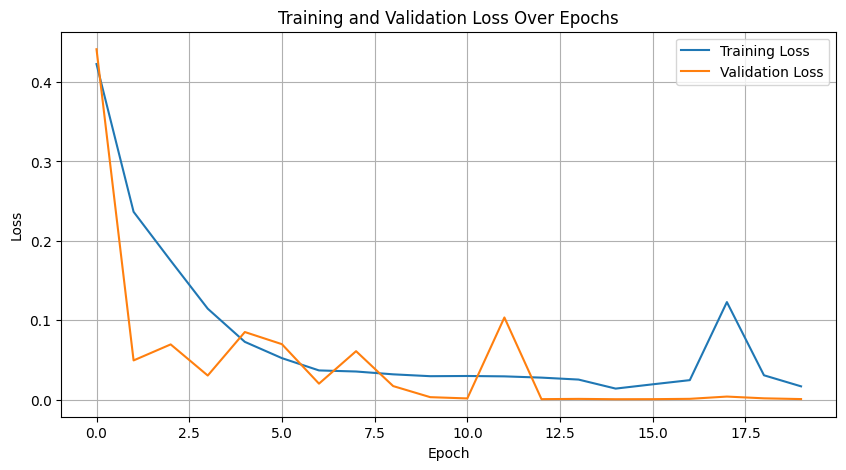

In [450]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [451]:
test_input_seqs = [string_to_seq(data, input_char_to_idx, max_input_length) for data in test_df['data']]
test_dataset = DateDataset(test_input_seqs, [[0]*max_output_length for _ in test_input_seqs])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [452]:
predictions = []
for input_seq, _ in tqdm(test_loader, desc='Generating Predictions'):
    input_seq = input_seq.to(device)
    predicted_seq = model.generate(input_seq)
    for seq in predicted_seq:
        date_str = ''.join([output_idx_to_char[idx.item()] for idx in seq 
                           if idx.item() not in [output_char_to_idx['<EOS>'], output_char_to_idx['<PAD>']]])
        predictions.append(date_str)

submission_df = pd.DataFrame({'id': test_df['id'], 'label': predictions})
submission_df.to_csv('submission-7.csv', index=False)
print("Submission file 'submission.csv' created.")

Generating Predictions:   0%|          | 0/147 [00:00<?, ?it/s]

Submission file 'submission.csv' created.


In [453]:
def post_process_date(date_str):
    if len(date_str) != 10 or date_str[2] != '-' or date_str[5] != '-':
        return '01-01-2007'
    day, month, year = date_str.split('-')
    if not (day.isdigit() and month.isdigit() and year.isdigit()):
        return '01-01-2007'
    day, month, year = int(day), int(month), int(year)
    if not (1 <= day <= 31 and 1 <= month <= 12 and 2007 <= year <= 2077):
        return '01-01-2007'
    return date_str

In [454]:
def predict_date(model, input_string, input_char_to_idx, output_idx_to_char, max_input_length=50, max_output_length=11, device='cpu'):
    input_seq = string_to_seq(input_string, input_char_to_idx, max_input_length)
    input_tensor = torch.tensor([input_seq], dtype=torch.long).to(device)
    
    model.eval()
    with torch.no_grad():
        predicted_seq = model.generate(input_tensor, max_length=max_output_length)

    date_str = ''.join([output_idx_to_char[idx.item()] for idx in predicted_seq[0] if idx.item() not in [output_char_to_idx['<EOS>'], output_char_to_idx['<PAD>']]])

    date_str = post_process_date(date_str)
    
    return date_str

In [488]:
question = "24 фебруара 2007"

In [489]:
predicted_date = predict_date(model, question, input_char_to_idx, output_idx_to_char, max_input_length=max_input_length, max_output_length=max_output_length, device=device)

print(f"Question: {question}")
print(f"Predicted Date: {predicted_date}")

Question: 24 фебруара 2007
Predicted Date: 24-02-2007
